<a href="https://colab.research.google.com/github/s26673/POSI_MON1/blob/main/EWD_11_cwiczenia_5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Praca na zajęciach / domowa

Dla danych dotyczących pasażerów statku Titanic z następującymi kolumnami:
- PassengerId: atrybut z identyfikatorem pasażera
- Survived: **atrubut decyzyjny**, gdzie 1 oznacza że pasażer przeżył, a 0 że nie (atrybut binarny)
- Name: atrybut z imieniem pasażera
- SibSp: atrybut dotyczący liczby rodzeństwa na pokładzie
- Parch: atrybut opisujący liczbę rodziców na pokładzie
- Ticket: atrybut zawierający numer biletu pasażera
- Fare: cena biletu
- Cabin: numer kabiny w której zakwaterowany był pasażer
- Embarked: port z którego pasażer wsiadł na pokład (C = Cherbourg, Q = Queenstown, S = Southampton)

Dokonaj dokładnej analizy tych danych:
1. Oblicz statystyki pozycyjne i rozproszenia
2. W przypadku atrybutów kategorycznych, zidentyfikuj które z nich są całkowicie lub w większości unikalne
3. Zbadaj rozkład klas atrybutów
4. Zidentyfikuj w danych wartości brakujące
5. Zidentyfikuj w danych wartości odstające

Przygotuj dane:
1. Zadecyduj, co zrobić z wartościami brakującymi i odstającymi
2. Pozbądź się kolumn z wartościami niepowtarzalnymi
3. Dokonaj kodowania zmiennych kategorycznych
4. Znormalizuj wartości atrybutu Age

Po przygotowaniu danych, wyświetl ich macierz korelacji


# Analiza danych Titanic (EDA)

In [5]:
#import bibliotek
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import files
uploaded = files.upload()

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

Saving Titanic-Dataset.csv to Titanic-Dataset.csv


##Załadowanie i zrozumienie danych

In [7]:
file_path = "Titanic-Dataset.csv"
df = pd.read_csv(file_path)

print('\nPodgląd 11 pierwszych wierszy wczytanego pliku Titanic-Dataset.csv')
head_preview = df.head(11)
print(head_preview)

print('\nwyświetlenie informacji o danych i ich brakach:')
print(df.info())

df.isna().any()


Podgląd 11 pierwszych wierszy wczytanego pliku Titanic-Dataset.csv
    PassengerId  Survived  Pclass  \
0             1         0       3   
1             2         1       1   
2             3         1       3   
3             4         1       1   
4             5         0       3   
5             6         0       3   
6             7         0       1   
7             8         0       3   
8             9         1       3   
9            10         1       2   
10           11         1       3   

                                                 Name     Sex   Age  SibSp  \
0                             Braund, Mr. Owen Harris    male  22.0      1   
1   Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                              Heikkinen, Miss. Laina  female  26.0      0   
3        Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                            Allen, Mr. William Henry    male  35.0      0   
5                  

,0
PassengerId,False
Survived,False
Pclass,False
Name,False
Sex,False
Age,True
SibSp,False
Parch,False
Ticket,False
Fare,False


In [8]:

df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


In [9]:
#automatyczne wczytanie (wyswietlenie) 5 wierszy pierwszych
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [10]:
df.isna().sum() / df.__len__()

,0
PassengerId,0.000000
Survived,0.000000
Pclass,0.000000
Name,0.000000
Sex,0.000000
Age,0.198653
SibSp,0.000000
Parch,0.000000
Ticket,0.000000
Fare,0.000000


Sprawdzenie braków w konkretnych kolumnach (ilościowo) i procentowo

In [11]:
# Sprawdzenie braków w konkretnych kolumnach (ilościowo)
missing_count = df[['Age', 'Cabin', 'Embarked']].isna().sum()

# Sprawdzenie braków procentowo
missing_percent = (df[['Age', 'Cabin', 'Embarked']].isna().sum() / len(df)) * 100

print("Liczba braków:\n", missing_count)
print("\nProcent braków:\n", missing_percent)

Liczba braków:
 Age         177
Cabin       687
Embarked      2
dtype: int64

Procent braków:
 Age         19.865320
Cabin       77.104377
Embarked     0.224467
dtype: float64


## Część 1: Analiza danych (EDA) na surowym stanie:

### Statystyki pozycyjne i rozproszenia

1. Oblicz statystyki pozycyjne i rozproszenia

In [12]:
#statystyki pozycyjne i rozproszenia
# użycie describe ()

statystyki = df.describe()
print (statystyki)

       PassengerId    Survived      Pclass         Age       SibSp  \
count   891.000000  891.000000  891.000000  714.000000  891.000000   
mean    446.000000    0.383838    2.308642   29.699118    0.523008   
std     257.353842    0.486592    0.836071   14.526497    1.102743   
min       1.000000    0.000000    1.000000    0.420000    0.000000   
25%     223.500000    0.000000    2.000000   20.125000    0.000000   
50%     446.000000    0.000000    3.000000   28.000000    0.000000   
75%     668.500000    1.000000    3.000000   38.000000    1.000000   
max     891.000000    1.000000    3.000000   80.000000    8.000000   

            Parch        Fare  
count  891.000000  891.000000  
mean     0.381594   32.204208  
std      0.806057   49.693429  
min      0.000000    0.000000  
25%      0.000000    7.910400  
50%      0.000000   14.454200  
75%      0.000000   31.000000  
max      6.000000  512.329200  


### Unikalne wartości

2. W przypadku atrybutów kategorycznych, zidentyfikuj które z nich są całkowicie lub w większości unikalne

In [13]:
# sprawdzenie, które kolumny tekstowe mają prawie same unikalne wartości
for col in df.select_dtypes(include=['object']).columns:
    uniqueness = df[col].nunique() / len(df)
    print(f"{col} - stopień unikalności: {uniqueness:.4f}")

Name - stopień unikalności: 1.0000
Sex - stopień unikalności: 0.0022
Ticket - stopień unikalności: 0.7643
Cabin - stopień unikalności: 0.1650
Embarked - stopień unikalności: 0.0034


## 3. Zbadaj rozkład klas atrybutów

In [14]:
# kto przeżył
print(df['Survived'].value_counts(normalize=True))

Survived
0    0.616162
1    0.383838
Name: proportion, dtype: float64


In [31]:
# Rozszerzone badanie rozkładu cech kategorycznych (klas)
cechy = ['Survived', 'Pclass', 'Sex', 'Embarked']

for col in cechy:
    print(f"\nRozkład dla kolumny {col}:")
    print(df[col].value_counts(normalize=True) * 100)


Rozkład dla kolumny Survived:
Survived
0    61.616162
1    38.383838
Name: proportion, dtype: float64

Rozkład dla kolumny Pclass:
Pclass
3    55.106622
1    24.242424
2    20.650954
Name: proportion, dtype: float64

Rozkład dla kolumny Sex:
Sex
male      64.758698
female    35.241302
Name: proportion, dtype: float64

Rozkład dla kolumny Embarked:
Embarked
S    72.440945
C    18.897638
Q     8.661417
Name: proportion, dtype: float64


/tmp/ipykernel_3822/2398345081.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Survived', ax=axes[0], palette='viridis')
/tmp/ipykernel_3822/2398345081.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Pclass', ax=axes[1], palette='magma')


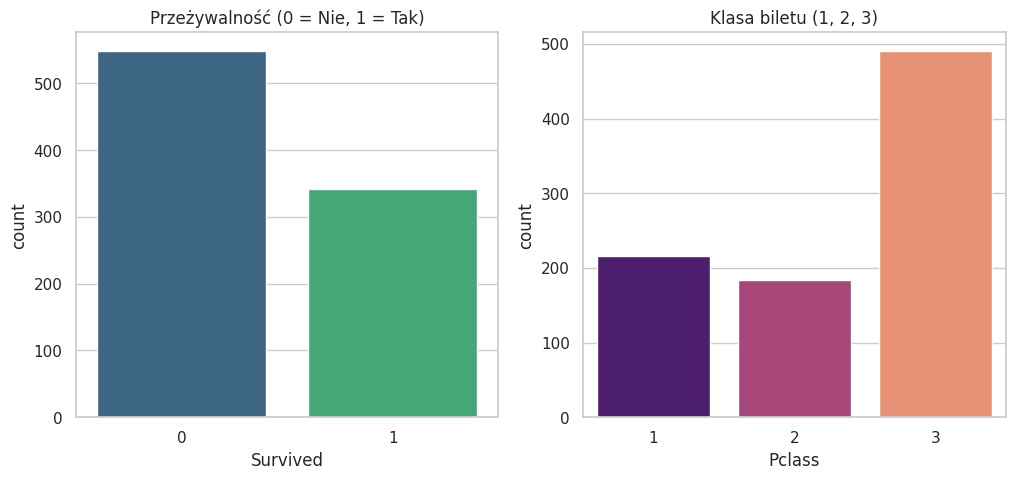

In [43]:
# Ustawienie stylu wykresów
sns.set_theme(style="whitegrid")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Wykres survived
sns.countplot(data=df, x='Survived', ax=axes[0], palette='viridis')
axes[0].set_title('Przeżywalność (0 = Nie, 1 = Tak)')

# Wykres klas biletów - pclass
sns.countplot(data=df, x='Pclass', ax=axes[1], palette='magma')
axes[1].set_title('Klasa biletu (1, 2, 3)')

plt.show()



ValueError: Could not interpret value `Embarked` for `x`. An entry with this name does not appear in `data`.

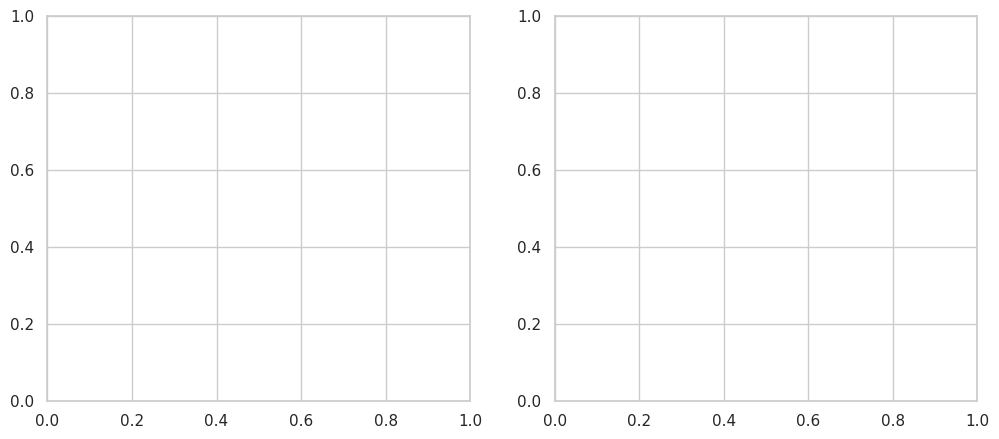

In [44]:
sns.set_theme(style="whitegrid")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
# wykres embarked
sns.countplot (data=df, x='Embarked', ax=axes[0], palette='magma')
axes[0].set_title('Port zaokrętowania (C = Cherbourg, Q = Queenstown, S = Southampton)')
plt.show()

# wykres sex
sns.countplot (data=df, x='Sex', ax=axes[1], palette='viridis')
axes[1].set_title('Płeć')
plt.show()

/tmp/ipykernel_3822/209842782.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=['Cherbourg', 'Queenstown', 'Southampton'], y=port_counts, ax=axes[0], palette='magma')
/tmp/ipykernel_3822/209842782.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Sex', ax=axes[1], palette='viridis')
/tmp/ipykernel_3822/209842782.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(['Mężczyźni', 'Kobiety'])


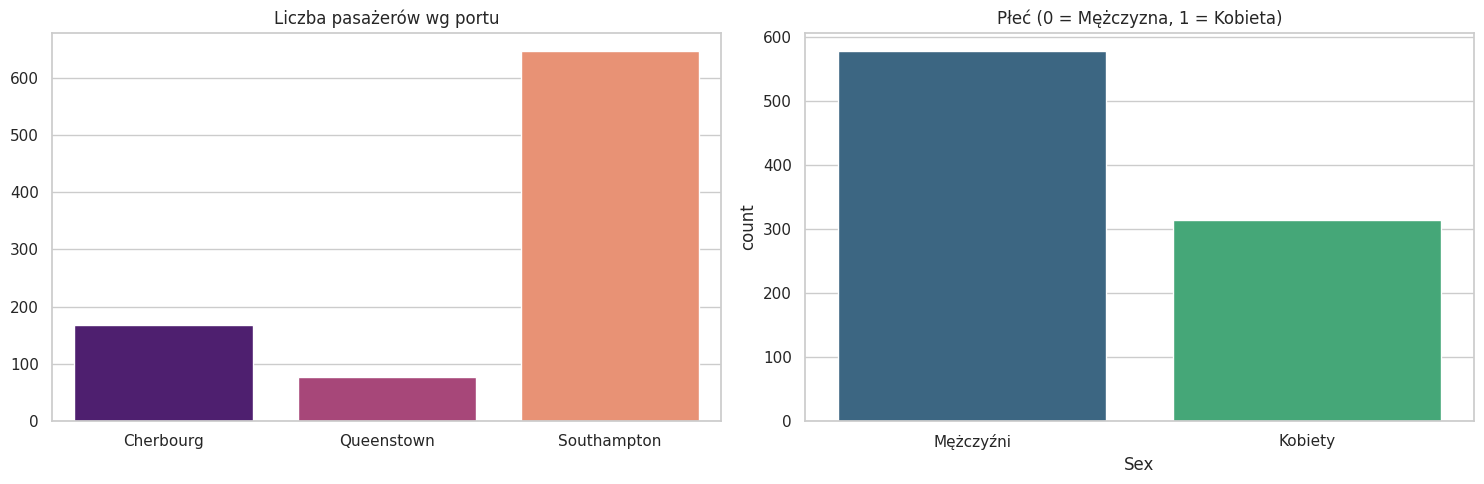

In [45]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

port_counts = [df['Port_C'].sum(), df['Port_Q'].sum(), df['Port_S'].sum()]
sns.barplot(x=['Cherbourg', 'Queenstown', 'Southampton'], y=port_counts, ax=axes[0], palette='magma')
axes[0].set_title('Liczba pasażerów wg portu')

sns.countplot(data=df, x='Sex', ax=axes[1], palette='viridis')
axes[1].set_title('Płeć (0 = Mężczyzna, 1 = Kobieta)')
axes[1].set_xticklabels(['Mężczyźni', 'Kobiety'])

plt.tight_layout()
plt.show()

In [ ]:

# wykres embarked
sns.countplot (data=df, x='Embarked', ax=axes[2], palette='magma')
axes[2].set_title('Rozkład klas: Port zaokrętowania (C = Cherbourg, Q = Queenstown, S = Southampton)')
plt.show()

In [24]:

# wykres embarked
sns.countplot (data=df, x='Embarked', ax=axes[0], palette='magma')
axes[0].set_title('Rozkład klas: Port zaokrętowania (C = Cherbourg, Q = Queenstown, S = Southampton)')
plt.show()


/tmp/ipykernel_3822/296268450.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot (data=df, x='Embarked', ax=axes[0], palette='magma')


###Wartości odstające

5. Zidentyfikuj w danych wartości odstające


In [15]:
#Z-score mówi nam, o ile odchyleń standardowych dana wartość różni się od średniej
k = 3
numerical_columns = ['Age', 'Fare', 'SibSp', 'Parch']
df['z_score_outlier'] = ''

for col in numerical_columns:
    # obliczenie z-score (należy usunąć NaN przy obliczeniach, żeby nie psuły średniej)
    temp_col = df[col].dropna()
    mean = temp_col.mean()
    std = temp_col.std()

    # znalezienie outlierów dla tej kolumny
    outliers = (df[col] - mean).abs() > k * std
    df.loc[outliers, 'z_score_outlier'] += f'{col} outlier, '

# Wyświetlenie podsumowania procentowego outlierów na kolumnę
for col in numerical_columns:
    count = df['z_score_outlier'].str.contains(col).sum()
    print(f"Outliery w {col}: {count} ({count/len(df)*100:.2f}%)")

Outliery w Age: 2 (0.22%)
Outliery w Fare: 20 (2.24%)
Outliery w SibSp: 30 (3.37%)
Outliery w Parch: 15 (1.68%)


### wniosek dot. outlierów

Analiza metodą Z-score ($k=3$) wykazała obecność wartości odstających, szczególnie w atrybutach Fare (2.24%) oraz SibSp (3.37%). Wskazuje to na dużą dysproporcję majątkową wśród pasażerów oraz obecność kilku bardzo licznych rodzin. Ponieważ wartości te są realistyczne i niosą istotną informację o strukturze pasażerów, nie zostały usunięte w procesie przygotowania danych.

###Sprawdzenie duplikatów, braków danych i ich wizualizacja

4. Zidentyfikuj w danych wartości brakujące

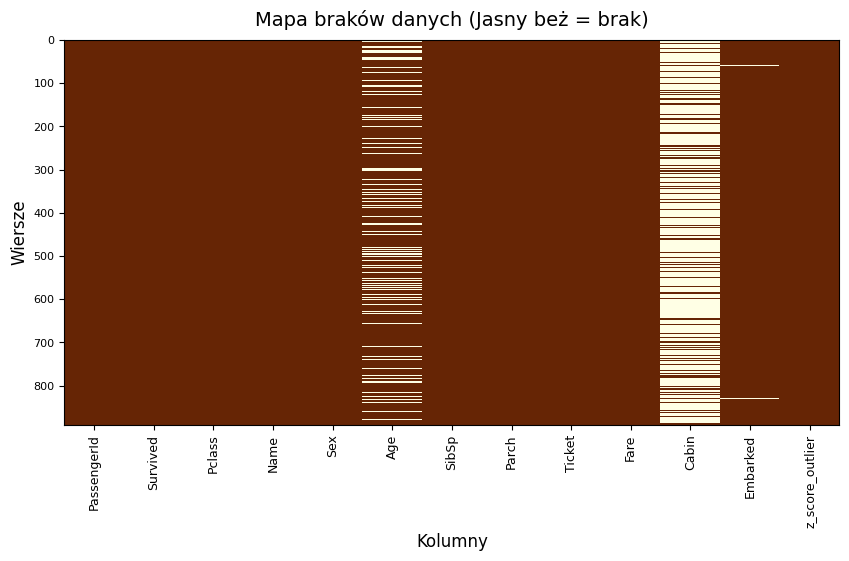

In [16]:
#mapa ciepła - wizualizacja braków danych

#każda kolumna na osi x to jedna cecha (np. age) w zbiorze danych
#każda kolumna na osi y to jeden rekord (pasazer)
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.imshow(df.isnull(), aspect='auto', interpolation='nearest', cmap='YlOrBr_r')
plt.title("Mapa braków danych (Jasny beż = brak)", fontsize=14, pad=10)
plt.xlabel("Kolumny", fontsize=12)
plt.ylabel("Wiersze", fontsize=12)

plt.xticks(
    ticks=range(len(df.columns)),
    labels=df.columns,
    rotation=90,
    fontsize=9
)
plt.yticks(fontsize=8)


plt.show()

#ciemny brązowy - wartość istnieje
#jasny beżowy - wartość brakujaca (NaN)


###Interpretacja mapy:

Jasne pionowe pasy to kolumny z brakami (tu: Age, Cabin, Embarked).

Wizualizacja braków na mapie pomaga szybko zauważyć, które kolumny wymagają uzupełnienia.

In [17]:
# czy są jakieś duplikaty?
dupes = df.duplicated().sum()
print(dupes)

0


###Podsumowanie
W tym zbiorze nie ma duplikatów (każdy pasażer to unikalny rekord).

####-> brakuje:

*   age - u 177 pasażerów
*   cabin - u 687 pasażerów (najwięcej)
*   embarked - u 2 pasażerów

Najwięcej braków występuje w Cabin, następnie w Age, pojedyncze w Embarked.

# Przygotowanie danych

##Czyszczenie danych

1. Zadecyduj, co zrobić z wartościami brakującymi i odstającymi


In [ ]:
# DECYZJA DOT. OUTLIERÓW:
# Zdecydowałam o pozostawieniu wartości odstających w kolumnach Age, Fare, SibSp i Parch.
# Uzasadnienie: Są to dane realistyczne (wiek seniorów, ceny luksusowych kabin, duże rodziny).
# Ich usunięcie pozbawiłoby model kluczowych informacji o statusie społecznym pasażerów.

Uzasadnienie imputacji (uzupełniania braków danych) w zbiorze titanic:


---



*   kolumna **Age** jest kolumną numeryczną; występuje w niej ok. **20% brakujących wartosci**; **braki uzupełniono medianą**, ponieważ jest odporna na wartości odstające i lepiej reprezentuje typowy wiek pasażera niż średnia, zastosowanie mediany pozwala zachować wszystkie obserwacje bez zniekształcania rozkładu
*   kolumna **Embarked** jest kolumną kategoryczną (object); brakujących wartosci** jest tylko **2**; braki uzupełniono dominującą wartością (modą) - najczęstszy port
*   kolumna **Cabin** jest kolumną tekstową (object); braków jest aż **77%**; w tym przypadku zdecydowano się nie usuwać kolumny, tylko zastąpić puste wartości tekstem "Unknown" i dodać kolumnę logiczną "HasCabin", wskazujaca czy pasażer miał przypisaną kabinę czy też nie (może sam fakt posiadania lub brak kabiny jest istotny np. czy osoby z kabina miała większe szanse na przeżycie lub mozna sprawdzić ceny biletów vs numer kabiny(sektor))

In [33]:
# 1. Uzupełnienie brakujacych wartości Age medianą
df["Age"] = df["Age"].fillna(df["Age"].median())

# 2. Uzupełnienie brakujacych wartości Embarked najczęstszą wartością
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])

# 3. Uzupełnienie brakujacych wartości Cabin ciągiem znaków "Unknown"
df["Cabin"] = df["Cabin"].fillna("Unknown")


df["HasCabin"] = df["Cabin"].apply(lambda x: 0 if x == "Unknown" else 1)
print(df.head())
# 4. ponowne sprawdzenie ew. braków
print("Pozostałe braki po czyszczeniu:")
print(df.isnull().sum())

   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare    Cabin Embarked z_score_outlier  \
0      0         A/5 21171   7.2500  Unknown        S                   
1      0          PC 17599  71.2833      C85        C                   
2      0  STON/O2. 3101282   7.9250  Unknown        S                   
3      0            113803  

## statystyki opisowe vol.2

In [34]:
print('Statystyki opisowe (tylko dla kolumn numerycznych):')
df.describe().T

Statystyki opisowe (tylko dla kolumn numerycznych):


,count,mean,std,min,25%,50%,75%,max
PassengerId,891.0,446.000000,257.353842,1.00,223.5000,446.0000,668.5,891.0000
Survived,891.0,0.383838,0.486592,0.00,0.0000,0.0000,1.0,1.0000
Pclass,891.0,2.308642,0.836071,1.00,2.0000,3.0000,3.0,3.0000
Age,891.0,29.361582,13.019697,0.42,22.0000,28.0000,35.0,80.0000
SibSp,891.0,0.523008,1.102743,0.00,0.0000,0.0000,1.0,8.0000
Parch,891.0,0.381594,0.806057,0.00,0.0000,0.0000,0.0,6.0000
Fare,891.0,32.204208,49.693429,0.00,7.9104,14.4542,31.0,512.3292
HasCabin,891.0,0.228956,0.420397,0.00,0.0000,0.0000,0.0,1.0000


In [35]:
print('\nStatystyki dla danych kategorycznych:')
print(df.describe(include='object').T)


Statystyki dla danych kategorycznych:
                count unique                  top freq
Name              891    891  Dooley, Mr. Patrick    1
Sex               891      2                 male  577
Ticket            891    681               347082    7
Cabin             891    148              Unknown  687
Embarked          891      3                    S  646
z_score_outlier   891      6                       825


## 2. Pozbądź się kolumn z wartościami niepowtarzalnymi

In [36]:
# Usuwamy kolumny o wysokiej unikalności, które nie niosą wartości statystycznej
cols_to_drop = ['PassengerId', 'Name', 'Ticket', 'Cabin']

# Sprawdzamy czy kolumny istnieją (na wypadek ponownego uruchomienia komórki)
df.drop(columns=[c for c in cols_to_drop if c in df.columns], inplace=True)

print("Kolumny po usunięciu:", df.columns.tolist())

Kolumny po usunięciu: ['Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked', 'z_score_outlier', 'HasCabin']


## 3. Dokonaj kodowania zmiennych kategorycznych

In [37]:
# Kodowanie płci (0 = mężczyzna, 1 = kobieta)
df['Sex'] = df['Sex'].map({'male': 0, 'female': 1})

# Kodowanie portów - Embarked
# dtype=int sprawi, że otrzymamy 0 i 1 zamiast True/False
df = pd.get_dummies(df, columns=['Embarked'], prefix='Port', dtype=int)

print("Podgląd danych po kodowaniu:")
display(df.head())

Podgląd danych po kodowaniu:


,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,z_score_outlier,HasCabin,Port_C,Port_Q,Port_S
0,0,3,0,22.0,1,0,7.2500,,0,0,0,1
1,1,1,1,38.0,1,0,71.2833,,1,1,0,0
2,1,3,1,26.0,0,0,7.9250,,0,0,0,1
3,1,1,1,35.0,1,0,53.1000,,1,0,0,1
4,0,3,0,35.0,0,0,8.0500,,0,0,0,1


## 4. Znormalizuj wartości atrybutu Age


In [38]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
# Dopasowujemy i transformujemy kolumnę Age
df['Age'] = scaler.fit_transform(df[['Age']])

print("Statystyki wieku po normalizacji (min: 0, max: 1):")
print(df['Age'].describe())

Statystyki wieku po normalizacji (min: 0, max: 1):
count    891.000000
mean       0.363679
std        0.163605
min        0.000000
25%        0.271174
50%        0.346569
75%        0.434531
max        1.000000
Name: Age, dtype: float64


Wykres pudełkowy dla wieku


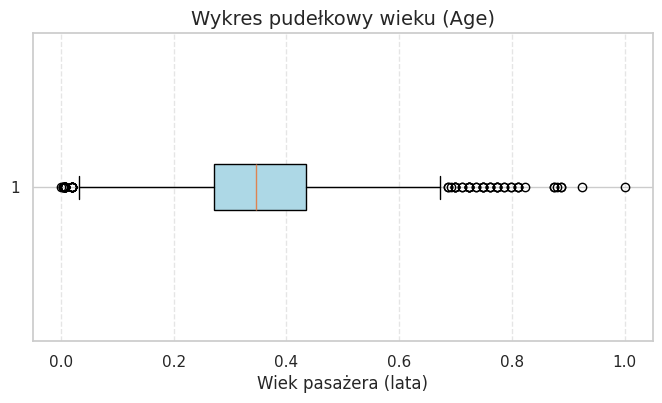

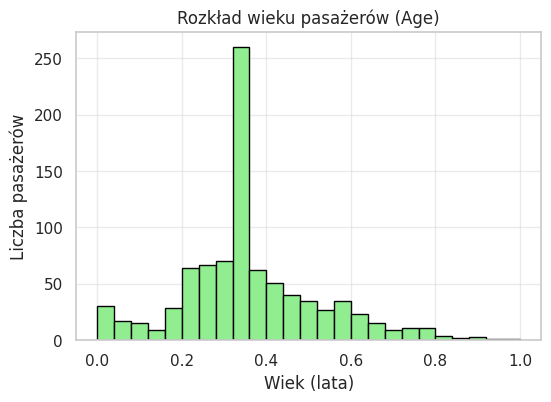

In [39]:
import matplotlib.pyplot as plt
print('Wykres pudełkowy dla wieku')

plt.figure(figsize=(8,4))
plt.boxplot(df["Age"], vert=False, patch_artist=True,boxprops=dict(facecolor="lightblue"))
plt.title("Wykres pudełkowy wieku (Age)", fontsize=14)
plt.xlabel("Wiek pasażera (lata)", fontsize=12)
plt.grid(axis="x", linestyle="--", alpha=0.5)
plt.show()


plt.figure(figsize=(6,4))
plt.hist(df["Age"], bins=25, color="lightgreen", edgecolor="black")
plt.title("Rozkład wieku pasażerów (Age)")
plt.xlabel("Wiek (lata)")
plt.ylabel("Liczba pasażerów")
plt.grid(alpha=0.4)
plt.show()

# Po przygotowaniu danych, wyświetl ich macierz korelacji

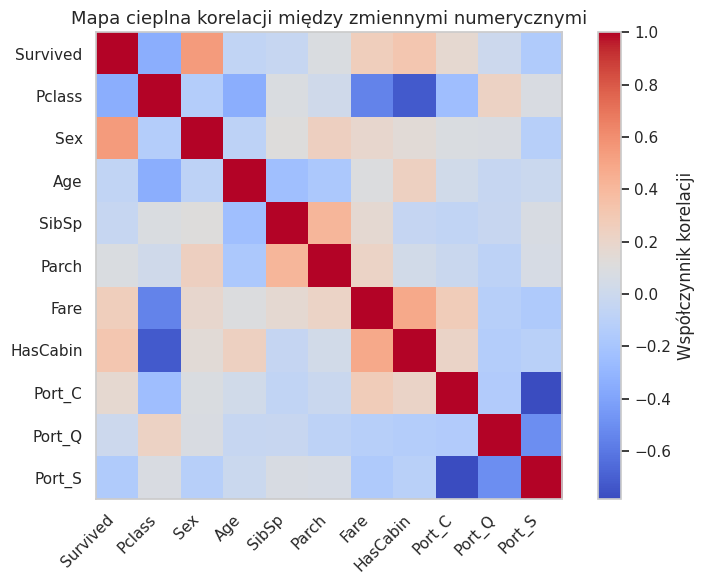

Korelacje między zmiennymi numerycznymi:
          Survived  Pclass   Sex   Age  SibSp  Parch  Fare  HasCabin  Port_C  \
Survived      1.00   -0.34  0.54 -0.06  -0.04   0.08  0.26      0.32    0.17   
Pclass       -0.34    1.00 -0.13 -0.34   0.08   0.02 -0.55     -0.73   -0.24   
Sex           0.54   -0.13  1.00 -0.08   0.11   0.25  0.18      0.14    0.08   
Age          -0.06   -0.34 -0.08  1.00  -0.23  -0.17  0.10      0.24    0.03   
SibSp        -0.04    0.08  0.11 -0.23   1.00   0.41  0.16     -0.04   -0.06   
Parch         0.08    0.02  0.25 -0.17   0.41   1.00  0.22      0.04   -0.01   
Fare          0.26   -0.55  0.18  0.10   0.16   0.22  1.00      0.48    0.27   
HasCabin      0.32   -0.73  0.14  0.24  -0.04   0.04  0.48      1.00    0.21   
Port_C        0.17   -0.24  0.08  0.03  -0.06  -0.01  0.27      0.21    1.00   
Port_Q        0.00    0.22  0.07 -0.03  -0.03  -0.08 -0.12     -0.13   -0.15   
Port_S       -0.15    0.07 -0.12 -0.01   0.07   0.06 -0.16     -0.10   -0.78   

In [41]:
import matplotlib.pyplot as plt
import numpy as np

# Obliczamy korelacje tylko dla kolumn numerycznych
corr = df.corr(numeric_only=True)

# Tworzymy mapę cieplną (heatmap)
plt.figure(figsize=(8,6))
plt.imshow(corr, cmap="coolwarm", interpolation="nearest")
plt.colorbar(label="Współczynnik korelacji")
plt.title("Mapa cieplna korelacji między zmiennymi numerycznymi", fontsize=13)

# Oznaczamy osie
plt.xticks(range(len(corr.columns)), corr.columns, rotation=45, ha="right")
plt.yticks(range(len(corr.columns)), corr.columns)

# Siatka dla lepszej czytelności
plt.grid(False)
plt.tight_layout()
plt.show()

# Wyświetlenie samej macierzy korelacji
print("Korelacje między zmiennymi numerycznymi:")
print(corr.round(2))


Wnioski z analizy korelacji danych Titanic
Płeć pasażera była decydującym czynnikiem przeżycia. Dodatnia korelacja (0.54) potwierdza, że kobiety miały statystycznie znacznie większą szansę na ratunek niż mężczyźni.

* Status socjoekonomiczny silnie determinował szanse na przeżycie. Ujemna korelacja z Pclass (-0.34) oraz dodatnia z Fare (0.26) wskazują, że pasażerowie klas wyższych i osoby z droższymi biletami byli traktowani priorytetowo.

* Posiadanie przypisanej kabiny zwiększało prawdopodobieństwo ratunku. Atrybut HasCabin wykazał istotną korelację z przeżywalnością (0.32), co wiąże się bezpośrednio z faktem, że kabiny posiadały głównie osoby z pierwszej klasy.

* Wiek pasażera nie miał istotnego wpływu statystycznego na ostateczny wynik. Bardzo niska korelacja (-0.06) sugeruje, że wiek sam w sobie nie był tak ważny jak płeć czy zamożność.

* Liczebność rodziny i port zaokrętowania miały marginalne znaczenie. Współczynniki korelacji dla tych zmiennych są bliskie zeru, co oznacza brak bezpośredniego wpływu na szansę przeżycia katastrofy.

* Istnieje silne powiązanie między zmiennymi ekonomicznymi. Bardzo wysoka ujemna korelacja między HasCabin a Pclass (-0.73) potwierdza, że brak danych o kabinie dotyczył niemal wyłącznie pasażerów klas niższych.

# Zadanie knn

### Przygotowanie danyh
2. Podziel dane na zbiór treningowy (70%), testowy(20%) oraz walidacyjny(10%)

### KNN
1. Wytrenuj prosty model KNN i, na podstawie danych walidacyjnych, sprawdź jego efektywność dla tych danych
2. Dokonaj transformacji wszystkich danych numerycznych modelu wykorzystując:
    - standaryzację
    - transformację sigmoidalną
    - transformację logarytmiczną
Jaka jest różnica w jakości predykcji prostego modelu KNN w zależności od dobranej transformacji? Sprawdź to wykorzystując zbiór walidacyjny.
3. Wykorzystując metodę **forward selection** na tym przetransformowanym zbiorze, który dla prostego modelu dawał najlepsze wyniki, znajdź najbardziej przydatne atrybuty w tym modelu. W celu doboru atrybutów wykorzystaj zbiór danych walidacyjnych.
4. Wytrenuj 3 dodatkowe modele KNN na atrybutach uzyskanych z **forward selection**, z najlepiej sprawdzającą się transformacją, w celu testowania ich jakości wykorzystując dane walidacyjne.

## 2. Podziel dane na zbiór treningowy (70%), testowy(20%) oraz walidacyjny(10%)

In [57]:
from sklearn.model_selection import train_test_split

y = df['Survived']
x = df.drop(columns=['Survived'])


x_train, x_temp, y_train, y_temp = train_test_split(
    x, y, test_size=0.3, random_state=42
)


x_val, x_test, y_val, y_test = train_test_split(
    x_temp, y_temp, test_size=2/3, random_state=42
)


# zbiór	procent
#train	70%
#val	10%
#test	20%


print(x_train.shape, x_val.shape, x_test.shape)
# sprawdzenie rozmiarów danych

(623, 11) (89, 11) (179, 11)


## 1. Wytrenuj prosty model KNN i, na podstawie danych walidacyjnych, sprawdź jego efektywność dla tych danych

In [48]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier()
knn.fit(x_train, y_train)

ValueError: could not convert string to float: ''

In [49]:
# 1. Sprawdźmy, jakie typy danych masz w tej chwili w df
print("Typy danych w df przed czyszczeniem:")
print(df.dtypes)



Typy danych w df przed czyszczeniem:
Survived             int64
Pclass               int64
Sex                  int64
Age                float64
SibSp                int64
Parch                int64
Fare               float64
z_score_outlier     object
HasCabin             int64
Port_C               int64
Port_Q               int64
Port_S               int64
dtype: object


In [58]:
cols_to_drop = ['z_score_outlier'] # <- też bląd w nazwie, dlatego nie działało

In [52]:
from sklearn.neighbors import KNeighborsClassifier

# Remove the 'z_score_outlier' column from x_train as it contains string values
x_train_numeric = x_train.drop(columns=['z_score_outlier'])

knn = KNeighborsClassifier()
knn.fit(x_train_numeric, y_train)

KNeighborsClassifier()

In [53]:
knn.classes_

array([0, 1])

## 1. Wytrenuj prosty model KNN i, na podstawie danych walidacyjnych, sprawdź jego efektywność dla tych danych

In [54]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

# 1. Przygotowanie danych (usunięcie kolumny tekstowej z obu zbiorów)
# Upewnij się, że robisz to dla x_train i x_val
x_train_final = x_train.drop(columns=['z_score_outlier'], errors='ignore')
x_val_final = x_val.drop(columns=['z_score_outlier'], errors='ignore')

# 2. Wytrenowanie modelu
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(x_train_final, y_train)

# 3. Sprawdzenie efektywności na danych walidacyjnych
y_val_pred = knn.predict(x_val_final)
efektywnosc = accuracy_score(y_val, y_val_pred)

print(f"Efektywność modelu KNN na danych walidacyjnych: {efektywnosc:.2%}")

Efektywność modelu KNN na danych walidacyjnych: 82.02%


## 2. Dokonaj transformacji wszystkich danych numerycznych modelu wykorzystując:
    - standaryzację
    - transformację sigmoidalną
    - transformację logarytmiczną
Jaka jest różnica w jakości predykcji prostego modelu KNN w zależności od dobranej transformacji? Sprawdź to wykorzystując zbiór walidacyjny.

In [59]:
#Do podziału danych użyto losowania z parametrem stratify, aby zachować proporcje klas w zbiorach

In [56]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler

# Przygotowanie cech numerycznych
num_cols = ['Age', 'SibSp', 'Parch', 'Fare']
y = df['Survived']
X_raw = df.drop(columns=['Survived', 'z_score_outlier']) # Drop 'z_score_outlier' here

def check_knn(X_data, y_target):
    # Podział 70/10/20
    X_train, X_temp, y_train, y_temp = train_test_split(X_data, y_target, test_size=0.3, random_state=1234, stratify=y_target)
    X_test, X_val, y_test, y_val = train_test_split(X_temp, y_temp, test_size=0.3333, random_state=1234, stratify=y_temp)

    knn = KNeighborsClassifier()
    knn.fit(X_train, y_train)
    return accuracy_score(y_val, knn.predict(X_val))

# 1. Standaryzacja (Z-score)
X_std = X_raw.copy()
scaler = StandardScaler()
X_std[num_cols] = scaler.fit_transform(X_std[num_cols])
acc_std = check_knn(X_std, y)

# 2. Transformacja sigmoidalna (na danych zestandaryzowanych)
X_sig = X_std.copy()
X_sig[num_cols] = 1 / (1 + np.exp(-X_sig[num_cols]))
acc_sig = check_knn(X_sig, y)

# 3. Transformacja logarytmiczna
X_log = X_raw.copy()
X_log[num_cols] = np.log1p(X_log[num_cols])
acc_log = check_knn(X_log, y)

print(f"Accuracy - Standaryzacja: {acc_std:.4f}")
print(f"Accuracy - Sigmoida:      {acc_sig:.4f}")
print(f"Accuracy - Logarytm:      {acc_log:.4f}")

Accuracy - Standaryzacja: 0.8000
Accuracy - Sigmoida:      0.7778
Accuracy - Logarytm:      0.7667


najlepsze wyniki daje standaryzacja ((KNN opiera się na odległościach (np. euklidesowej), więc  różne skale (np. Fare vs Age) zaburzają wynik
standaryzacja wyrównuje wpływ wszystkich cech))


## 3. Wykorzystując metodę **forward selection** na tym przetransformowanym zbiorze, który dla prostego modelu dawał najlepsze wyniki, znajdź najbardziej przydatne atrybuty w tym modelu. W celu doboru atrybutów wykorzystaj zbiór danych walidacyjnych.

In [60]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

# używamy danych po standaryzacji
Xtr = X_std.copy()
y_target = y.copy()

# ponowny podział (taki sam jak wcześniej)
from sklearn.model_selection import train_test_split

X_train, X_temp, y_train, y_temp = train_test_split(
    Xtr, y_target, test_size=0.3, random_state=1234, stratify=y_target
)

X_test, X_val, y_test, y_val = train_test_split(
    X_temp, y_temp, test_size=0.3333, random_state=1234, stratify=y_temp
)

# lista wszystkich cech
features = list(X_train.columns)

selected_features = []
remaining_features = features.copy()

best_score = 0

print("START FORWARD SELECTION\n")

while remaining_features:
    scores = []

    for feature in remaining_features:
        current_features = selected_features + [feature]

        model = KNeighborsClassifier(n_neighbors=5)
        model.fit(X_train[current_features], y_train)

        preds = model.predict(X_val[current_features])
        score = accuracy_score(y_val, preds)

        scores.append((score, feature))

    # wybierz najlepszą cechę w tej iteracji
    scores.sort(reverse=True)
    best_new_score, best_feature = scores[0]

    # jeśli poprawia wynik → dodaj
    if best_new_score > best_score:
        selected_features.append(best_feature)
        remaining_features.remove(best_feature)
        best_score = best_new_score

        print(f"Dodano: {best_feature} | Accuracy: {best_score:.4f}")
    else:
        break

print("\nNajlepszy zestaw cech:", selected_features)
print("Końcowa dokładność:", best_score)

START FORWARD SELECTION

Dodano: Port_C | Accuracy: 0.6333
Dodano: Sex | Accuracy: 0.8111

Najlepszy zestaw cech: ['Port_C', 'Sex']
Końcowa dokładność: 0.8111111111111111


W celu znalezienia najbardziej istotnych atrybutów zastosowano metodę forward selection na danych po standaryzacji (która wcześniej dała najlepsze wyniki modelu KNN).

Proces polegał na:

rozpoczynaniu od pustego zbioru cech,
iteracyjnym dodawaniu kolejnych atrybutów,
wyborze tych, które poprawiają skuteczność modelu,
ocenie modelu na zbiorze walidacyjnym.
Wynik:

W wyniku zastosowania metody wybrano następujące cechy: Najlepszy zestaw cech: ['Port_C', 'Sex']
Końcowa dokładność: 0.8111111111111111

## 4. Wytrenuj 3 dodatkowe modele KNN na atrybutach uzyskanych z **forward selection**, z najlepiej sprawdzającą się transformacją, w celu testowania ich jakości wykorzystując dane walidacyjne.

najlepsza transformacja -> standaryzacja (X_std)
najlepsze cechy -> ['Port_C', 'Sex']

In [61]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

# wybrane cechy
best_features = ['Port_C', 'Sex']

# dane po standaryzacji (tak jak w forward selection)
Xtr = X_std.copy()

# ponowny podział (TEN SAM co wcześniej!)
from sklearn.model_selection import train_test_split

X_train, X_temp, y_train, y_temp = train_test_split(
    Xtr, y, test_size=0.3, random_state=1234, stratify=y
)

X_test, X_val, y_test, y_val = train_test_split(
    X_temp, y_temp, test_size=0.3333, random_state=1234, stratify=y_temp
)

# testujemy różne wartości k
for k in [3, 5, 7]:
    model = KNeighborsClassifier(n_neighbors=k)

    model.fit(X_train[best_features], y_train)

    preds = model.predict(X_val[best_features])
    acc = accuracy_score(y_val, preds)

    print(f"K={k} → Accuracy: {acc:.4f}")

K=3 → Accuracy: 0.6333
K=5 → Accuracy: 0.8111
K=7 → Accuracy: 0.8111


In [63]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

# wybrane cechy
best_features = ['Port_C', 'Sex']

# dane po standaryzacji (tak jak w forward selection)
Xtr = X_std.copy()

# ponowny podział (TEN SAM co wcześniej!)
from sklearn.model_selection import train_test_split

X_train, X_temp, y_train, y_temp = train_test_split(
    Xtr, y, test_size=0.3, random_state=1234, stratify=y
)

X_test, X_val, y_test, y_val = train_test_split(
    X_temp, y_temp, test_size=0.3333, random_state=1234, stratify=y_temp
)

# testujemy różne wartości k
for k in [100, 300, 600]:
    model = KNeighborsClassifier(n_neighbors=k)

    model.fit(X_train[best_features], y_train)

    preds = model.predict(X_val[best_features])
    acc = accuracy_score(y_val, preds)

    print(f"K={k} → Accuracy: {acc:.4f}")

K=100 → Accuracy: 0.8333
K=300 → Accuracy: 0.6556
K=600 → Accuracy: 0.6111
